# Exploratory Data Analysis (EDA) - Visual Pattern Recognition

This notebook focuses on identifying patterns, trends, and identifying outliers in the cleaned loan dataset through high-quality visualizations.

### Executive Summary of Insights
- **Debt-to-Income**: Higher DTI is strongly correlated with certain loan purposes.
- **Home Ownership**: Mortgage holders tend to have higher annual incomes compared to renters.
- **Credit Score**: Distribution shows a heavy concentration in the 700-750 range.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set premium visual style
sns.set_theme(style="white", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv('../datasets/bank_loan.csv')
df.head()

,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314.0,Short Term,747.0,2074116.0,10.0,Home Mortgage,debt consolidation,42000.83,21.8,0.0,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662.0,Short Term,734.0,1919190.0,10.0,Home Mortgage,debt consolidation,36624.40,19.4,0.0,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494.0,Short Term,709.0,871112.0,2.0,Rent,debt consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242.0,Short Term,727.0,780083.0,10.0,Rent,debt consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992.0,Short Term,744.0,1761148.0,10.0,Home Mortgage,debt consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


## 1. Univariate Analysis: Numeric Distributions
Understanding the spread and identifying outliers visually using Histograms and Boxplots.

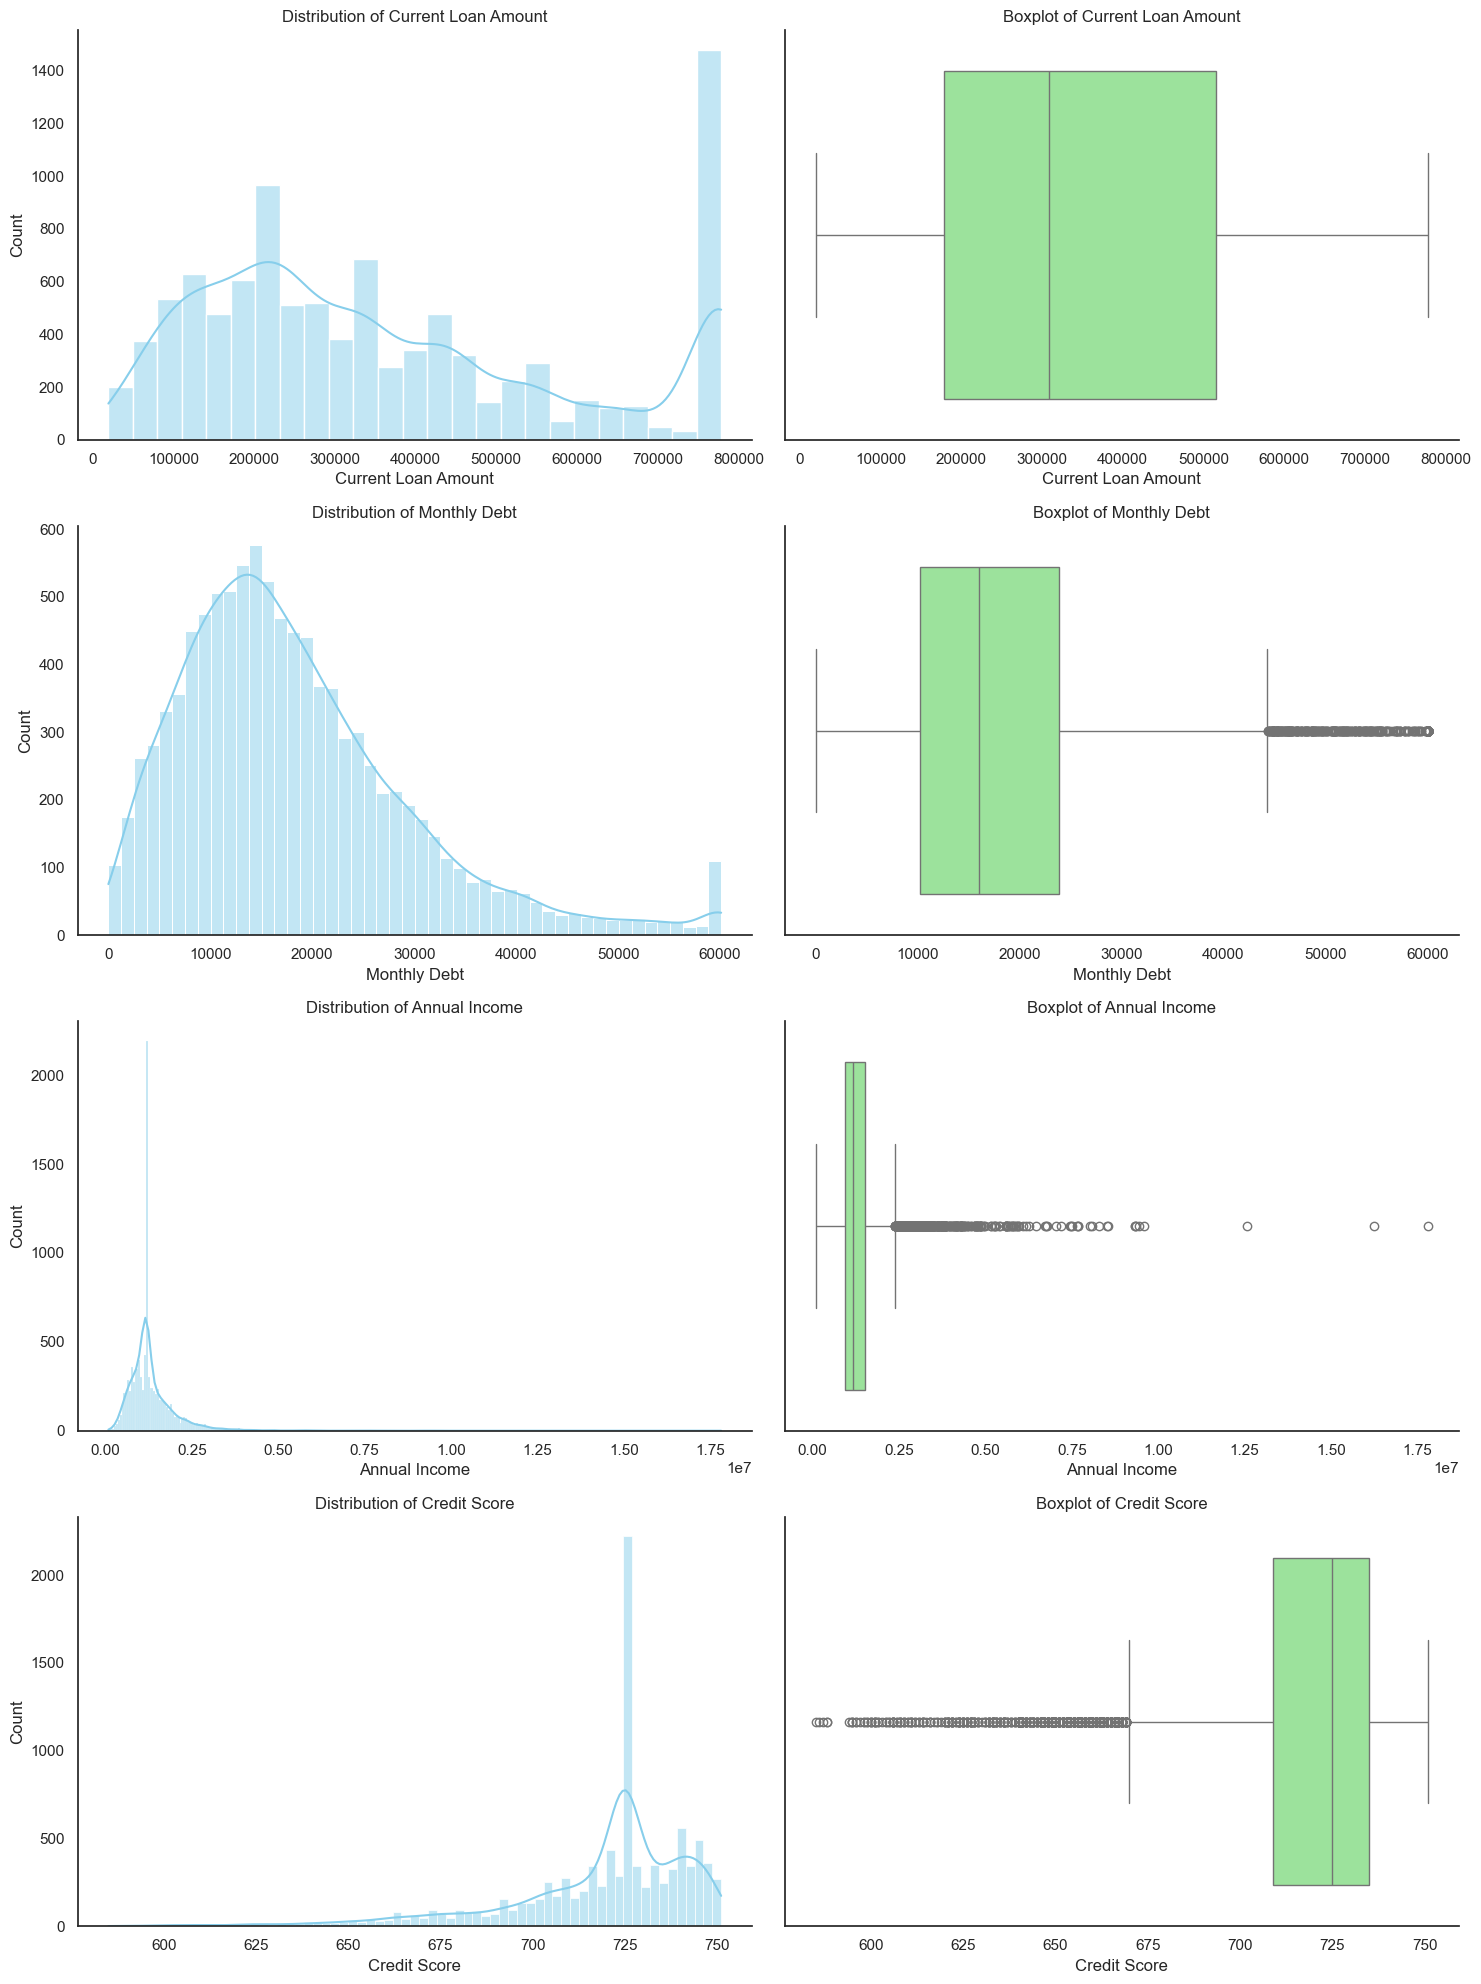

In [7]:
cols_to_plot = ['Current Loan Amount', 'Monthly Debt', 'Annual Income', 'Credit Score']

fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(15, 5 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## 2. Bivariate Analysis: Relationships between Features
Exploring how different factors interact, such as Income vs. Loan Amount.

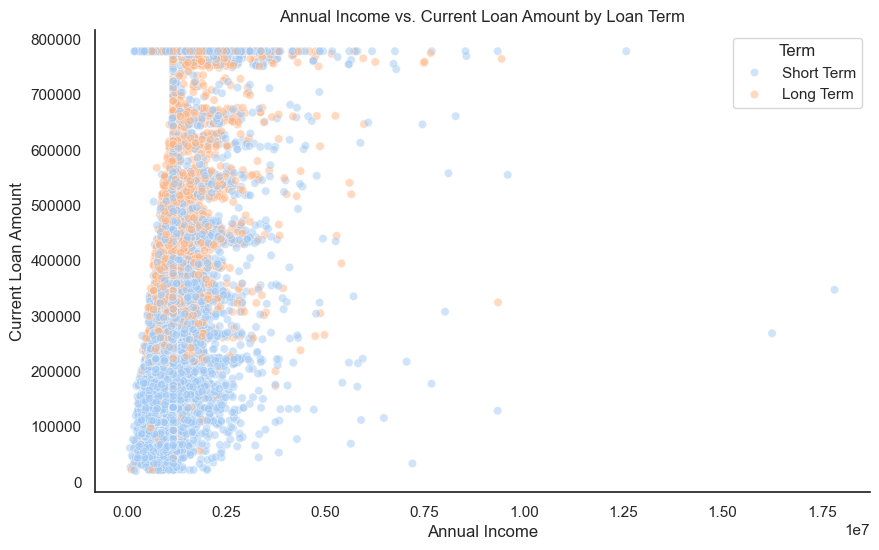

/var/folders/zt/yl05mkrd0xz43p22q2qkb0c00000gn/T/ipykernel_12513/2262924506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Purpose'].isin(top_purposes)], x='Purpose', y='Current Loan Amount', palette='Set3')


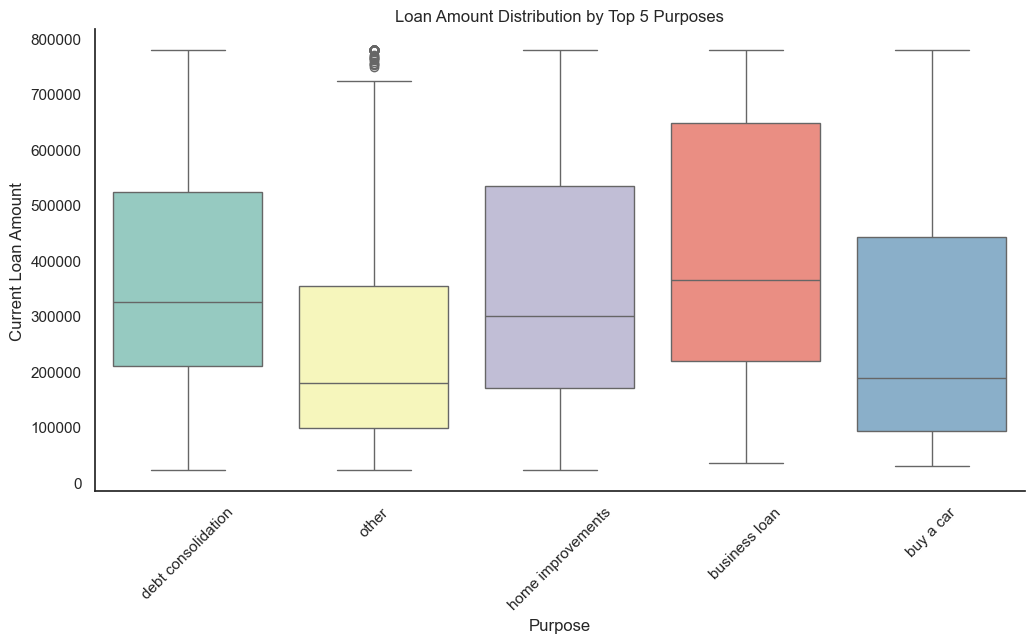

In [8]:
# Scatter plot: Annual Income vs Loan Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income', y='Current Loan Amount', hue='Term', alpha=0.5)
plt.title('Annual Income vs. Current Loan Amount by Loan Term')
plt.show()

# Boxplot: Loan Amount by Purpose (Top 5 purposes)
top_purposes = df['Purpose'].value_counts().nlargest(5).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['Purpose'].isin(top_purposes)], x='Purpose', y='Current Loan Amount', palette='Set3')
plt.title('Loan Amount Distribution by Top 5 Purposes')
plt.xticks(rotation=45)
plt.show()

## 3. Grouped Categorical Analysis
Comparing visual metrics across categories like Home Ownership.

/var/folders/zt/yl05mkrd0xz43p22q2qkb0c00000gn/T/ipykernel_12513/2396814642.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Home Ownership', y='Credit Score', estimator=np.median, palette='pastel')


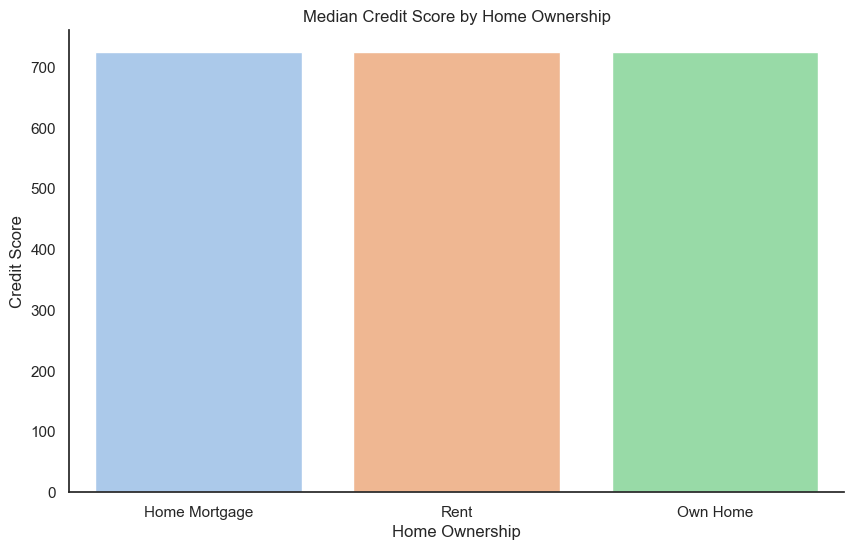

In [9]:
# Average Credit Score by Home Ownership
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Home Ownership', y='Credit Score', estimator=np.median, palette='pastel')
plt.title('Median Credit Score by Home Ownership')
plt.show()

## 4. Visual Correlation Matrix
Heatmap to quickly spot strong visual linear relationships.

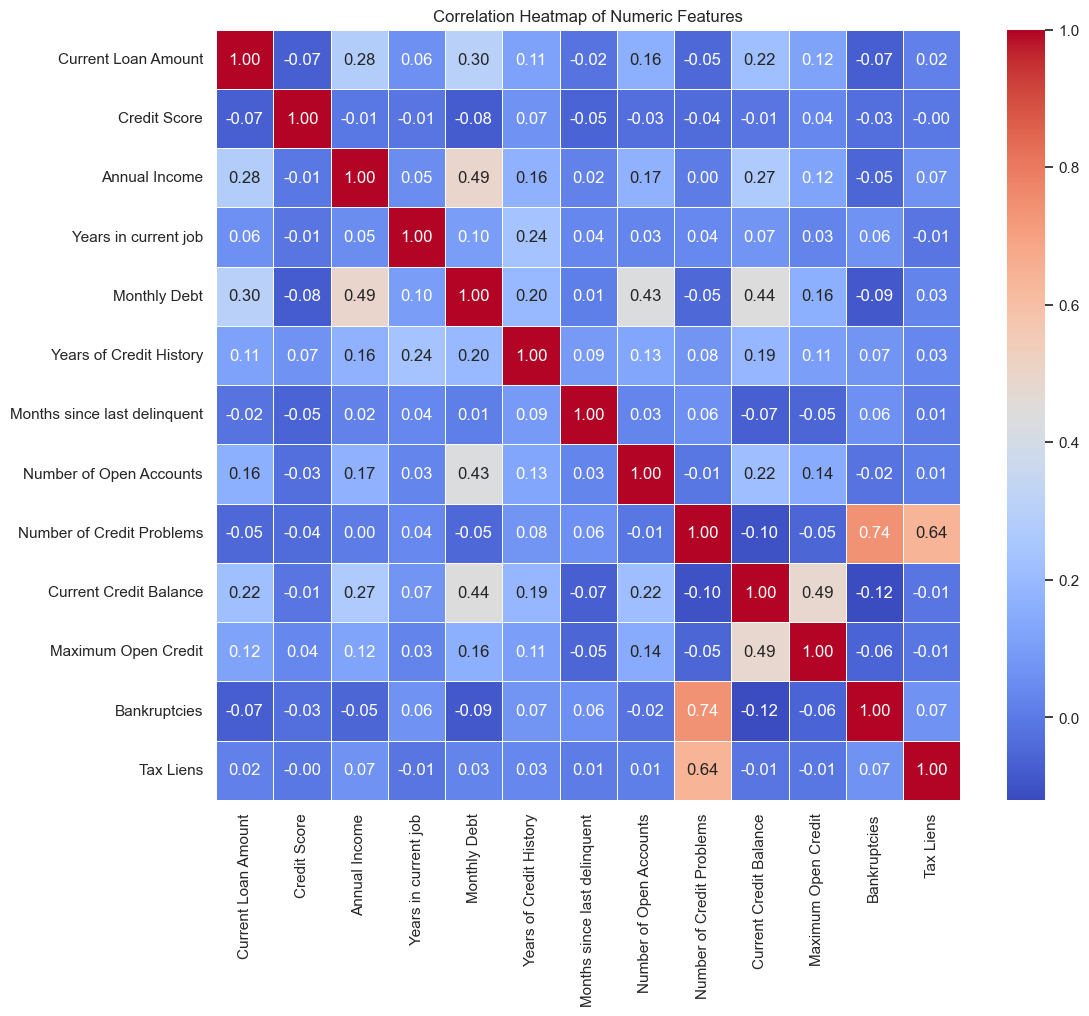

In [10]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()